In [1]:
from pathlib import Path
import logging
import os
import shutil

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import ras_commander
from ras_commander import (
    RasCmdr,
    RasFlowOptimization,
    init_ras_project,
    ras,
)
from ras_commander.RasUnsteady import RasUnsteady

logging.disable(logging.CRITICAL)
print(f"ras-commander {ras_commander.__version__}")

ras-commander 0.96.1


## Development Mode

For local source testing, run this notebook with `PYTHONPATH` pointed at the repository root. The committed import cell intentionally uses normal package imports so the notebook also works for installed ras-commander users.

# Native Flow Hydrograph Optimization

This notebook maps HEC-RAS Tutorial 13 Automated Flow Optimization to `RasFlowOptimization`. It configures a copied native optimization plan and executes through `RasCmdr`. If the command-line HEC-RAS run does not emit native trial rows, the notebook falls back to the ras-commander calibration pattern: parameterize the flow hydrograph multiplier, run candidate plans through `RasCmdr`, evaluate an HDF-derived objective, and compare before/after results.

## Workflow Coverage

| Tutorial step | ras-commander API |
| --- | --- |
| Read native optimization setup | `RasFlowOptimization.get_settings()` |
| Select scalable hydrographs | `RasFlowOptimization.list_flow_hydrographs()` |
| Enable native optimization on a copied plan | `RasFlowOptimization.copy_plan_with_optimization()` |
| Execute HEC-RAS | `RasFlowOptimization.compute_plan_and_get_trials()` / `RasCmdr.compute_plan()` |
| Fallback search if native trial output is unavailable | `RasUnsteady.update_flow_multiplier_by_station()` + `RasCmdr.compute_plan()` |
| Review results | HDF time-series extraction and plots |

## Parameters

In [2]:
def find_repo_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "ras_commander").exists():
            return candidate
    return start


def find_tutorial_project(repo_root):
    env_value = os.environ.get("RAS_TUTORIAL_13_PROJECT")
    candidates = []
    if env_value:
        candidates.append(Path(env_value).expanduser())
    candidates.extend(
        [
            repo_root / "example_projects" / "Example_FlowOptimization",
            Path("H:/Symphony/ras-commander/CLB-320/official_flow_optimization/extracted/Example_FlowOptimization"),
        ]
    )
    for candidate in candidates:
        if (candidate / "HydroFlowOptimization.prj").exists():
            return candidate
    return candidates[0] if candidates else repo_root / "example_projects" / "Example_FlowOptimization"


REPO_ROOT = find_repo_root(Path.cwd())
TUTORIAL_13_PROJECT = find_tutorial_project(REPO_ROOT)
WORK_ROOT = REPO_ROOT / "working" / "flow_hydrograph_optimization"
TRIAL_HDF_ROOT = WORK_ROOT / "trial_hdfs"

RAS_EXE = Path(os.environ.get("RAS_EXE", "C:/Program Files (x86)/HEC/HEC-RAS/6.4.1/Ras.exe"))
RAS_VERSION = str(RAS_EXE) if RAS_EXE.exists() else os.environ.get("RAS_VERSION", "6.4.1")

BASE_PLAN = "01"
TARGET_MODE = "stage"
TARGET_REFERENCE = "Yosemite Falls Vantage Point"
TARGET_VALUE = 3963.5
TARGET_TOLERANCE = 0.1
TARGET_HYDROGRAPHS = ["BCLine: Inflow"]
BOUNDARY_LABEL = "Inflow"
FLOW_AREA_NAME = "2DArea"

RUN_NATIVE_COMPUTE = os.environ.get("RAS_RUN_NATIVE_COMPUTE", "1").lower() not in {"0", "false", "no"}
RUN_FALLBACK_SEARCH = os.environ.get("RAS_RUN_FLOW_RATIO_FALLBACK", "1").lower() not in {"0", "false", "no"}
Q_MULT_TRIALS = [1.2, 0.9, 0.6]

print(f"Repository root: {REPO_ROOT}")
print(f"Tutorial project found: {(TUTORIAL_13_PROJECT / 'HydroFlowOptimization.prj').exists()}")
print(f"HEC-RAS executable/version: {RAS_VERSION}")

Repository root: C:\GH\symphony-workspaces\ras-commander\CLB-320
Tutorial project found: True
HEC-RAS executable/version: C:\Program Files (x86)\HEC\HEC-RAS\6.4.1\Ras.exe


## Prepare a Working Copy

In [3]:
project_file = TUTORIAL_13_PROJECT / "HydroFlowOptimization.prj"
project_available = project_file.exists()

if not project_available:
    print("Tutorial 13 project not found.")
    print(f"Expected project file: {project_file}")
    print("Set RAS_TUTORIAL_13_PROJECT to the extracted Example_FlowOptimization folder.")
    working_project = None
    ras_project = None
else:
    WORK_ROOT.mkdir(parents=True, exist_ok=True)
    working_project = WORK_ROOT / TUTORIAL_13_PROJECT.name
    if working_project.exists():
        shutil.rmtree(working_project)
    if TRIAL_HDF_ROOT.exists():
        shutil.rmtree(TRIAL_HDF_ROOT)
    TRIAL_HDF_ROOT.mkdir(parents=True, exist_ok=True)

    shutil.copytree(TUTORIAL_13_PROJECT, working_project)
    ras_project = init_ras_project(working_project, RAS_VERSION)

    display(ras_project.plan_df[["plan_number", "Plan Title", "Short Identifier"]])
    print(f"Working project: {working_project}")

,plan_number,Plan Title,Short Identifier
0,01,Base,Base


Working project: C:\GH\symphony-workspaces\ras-commander\CLB-320\working\flow_hydrograph_optimization\Example_FlowOptimization


## Inspect Native Optimization Settings

In [4]:
if project_available:
    settings = RasFlowOptimization.get_settings(BASE_PLAN, ras_object=ras_project)
    settings_preview = pd.Series({k: v for k, v in settings.items() if k != "raw_values"})
    display(settings_preview)

    hydrographs = RasFlowOptimization.list_flow_hydrographs(BASE_PLAN, ras_object=ras_project)
    display(hydrographs)
else:
    settings = None
    hydrographs = pd.DataFrame()

enabled                                                                   True
mode                                                                     stage
reference                              Ref Point: Yosemite Falls Vantage Point
reference_type                                                       Ref Point
reference_location                                Yosemite Falls Vantage Point
target_value                                                            3963.5
tolerance                                                                  0.1
initial_ratio                                                              1.0
min_ratio                                                                  0.5
max_ratio                                                                  1.0
max_iterations                                                              10
user_selected_hydrographs                                                 True
hydrographs                                         

,river,reach,station,storage_area,flow_area,bc_line,bc_type,interval,use_dss,dss_file,dss_path,line_number,optimization_hydrograph
0,,,,,2DArea,Inflow,Flow Hydrograph,1HOUR,True,.\Flow_Data\streamflow.dss,/MERCED R A HAPPY ISLES BRIDGE/YOSEMITE CA/FLO...,4,BCLine: Inflow


## Configure and Execute a Native Optimization Plan

In [5]:
if project_available:
    optimization_plan = RasFlowOptimization.copy_plan_with_optimization(
        BASE_PLAN,
        new_plan_shortid="Native Flow Opt",
        new_title="Native Flow Optimization",
        mode=TARGET_MODE,
        reference_location=TARGET_REFERENCE,
        target_value=TARGET_VALUE,
        tolerance=TARGET_TOLERANCE,
        hydrographs=TARGET_HYDROGRAPHS,
        min_ratio=0.5,
        max_ratio=1.0,
        max_iterations=10,
        ras_object=ras_project,
    )
    print(f"Created optimization plan: {optimization_plan}")
    display(pd.Series(RasFlowOptimization.get_settings(optimization_plan, ras_object=ras_project)).drop("raw_values"))
else:
    optimization_plan = None

Created optimization plan: 02


enabled                                                                   True
mode                                                                     stage
reference                              Ref Point: Yosemite Falls Vantage Point
reference_type                                                       Ref Point
reference_location                                Yosemite Falls Vantage Point
target_value                                                            3963.5
tolerance                                                                  0.1
initial_ratio                                                              1.0
min_ratio                                                                  0.5
max_ratio                                                                  1.0
max_iterations                                                              10
user_selected_hydrographs                                                 True
hydrographs                                         

In [6]:
native_result = None
native_trials = pd.DataFrame()

if project_available and RUN_NATIVE_COMPUTE:
    native_result = RasFlowOptimization.compute_plan_and_get_trials(
        optimization_plan,
        ras_object=ras_project,
        num_cores=4,
        verify=True,
        force_rerun=True,
    )
    print(native_result["compute_result"])
    native_trials = native_result["trial_results"]
    display(native_trials)

    if native_trials.empty:
        print(
            "Native HEC-RAS command-line compute completed, but no native flow "
            "optimization trial rows were written to the plan HDF or compute messages. "
            "The next section falls back to a ras-commander search over the inflow QMult."
        )
elif project_available:
    print("RUN_NATIVE_COMPUTE is disabled. Skipping native HEC-RAS execution.")

ComputeResult(SUCCESS, results_df_row=available)


,trial,ratio,difference,target,computed,mode,units,reference_location,converged,failed,source,source_path,source_dataset,message


Native HEC-RAS command-line compute completed, but no native flow optimization trial rows were written to the plan HDF or compute messages. The next section falls back to a ras-commander search over the inflow QMult.


## HDF Extraction Helpers

In [7]:
def _as_text(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="ignore").strip()
    return str(value).strip()


def plan_hdf_path(plan_number):
    return working_project / f"{ras_project.project_name}.p{str(plan_number).zfill(2)}.hdf"


def read_inflow_hydrograph(hdf_path):
    dataset_path = (
        "Event Conditions/Unsteady/Boundary Conditions/Flow Hydrographs/"
        f"2D: {FLOW_AREA_NAME} BCLine: {BOUNDARY_LABEL}"
    )
    with h5py.File(hdf_path, "r") as hdf:
        data = hdf[dataset_path][()]
    return pd.DataFrame({"days": data[:, 0], "flow_cfs": data[:, 1]})


def read_reference_wse(hdf_path, cell_index):
    base = "Results/Unsteady/Output/Output Blocks/Base Output/Unsteady Time Series"
    with h5py.File(hdf_path, "r") as hdf:
        time_days = hdf[f"{base}/Time"][()]
        wse = hdf[f"{base}/2D Flow Areas/{FLOW_AREA_NAME}/Water Surface"][:, cell_index]
    wse = np.where(wse < -1e20, np.nan, wse)
    return pd.DataFrame({"days": time_days, "wse_ft": wse})


def max_wse_by_cell(hdf_path):
    path = (
        "Results/Unsteady/Output/Output Blocks/Base Output/Unsteady Time Series/"
        f"2D Flow Areas/{FLOW_AREA_NAME}/Water Surface"
    )
    with h5py.File(hdf_path, "r") as hdf:
        data = hdf[path][()]
    data = np.where(data < -1e20, np.nan, data)
    return np.nanmax(data, axis=0)


def find_reference_cell(geometry_hdf, baseline_hdf, target_value, tolerance):
    with h5py.File(geometry_hdf, "r") as hdf:
        centers = hdf[f"Geometry/2D Flow Areas/{FLOW_AREA_NAME}/Cells Center Coordinate"][()]
        min_elev = hdf[f"Geometry/2D Flow Areas/{FLOW_AREA_NAME}/Cells Minimum Elevation"][()]

    baseline_max = max_wse_by_cell(baseline_hdf)
    finite = np.isfinite(baseline_max) & np.isfinite(min_elev)
    candidates = np.where(
        finite
        & (np.abs(min_elev - target_value) <= 0.15)
        & (baseline_max > target_value + tolerance)
    )[0]
    if len(candidates) == 0:
        candidates = np.where(finite)[0]

    best = min(
        candidates,
        key=lambda idx: (
            abs(float(min_elev[idx]) - target_value),
            abs(float(baseline_max[idx]) - target_value),
        ),
    )
    return {
        "cell_index": int(best),
        "x": float(centers[best, 0]),
        "y": float(centers[best, 1]),
        "min_elevation_ft": float(min_elev[best]),
        "baseline_max_wse_ft": float(baseline_max[best]),
    }


def trial_metrics_from_hdfs(trial_hdfs, reference_cell):
    rows = []
    for trial, (qmult, hdf_path) in enumerate(trial_hdfs.items(), start=1):
        max_wse = max_wse_by_cell(hdf_path)[reference_cell["cell_index"]]
        difference = float(max_wse - TARGET_VALUE)
        rows.append(
            {
                "trial": trial,
                "qmult": qmult,
                "hydrograph_scale_vs_base": qmult / Q_MULT_TRIALS[0],
                "computed_wse_ft": float(max_wse),
                "target_wse_ft": TARGET_VALUE,
                "difference_ft": difference,
                "objective_ft": abs(difference),
                "within_tolerance": abs(difference) <= TARGET_TOLERANCE,
                "hdf_path": str(hdf_path),
            }
        )
    return pd.DataFrame(rows)

## Fallback: ras-commander Flow Multiplier Search

The native settings remain on the copied plan. The fallback below demonstrates the same calibration/search pattern used by `RasCalibrate`: update a model parameter, run HEC-RAS through `RasCmdr`, calculate an objective from the result HDF, and select the best run. Here the parameter is the inflow `Flow Hydrograph QMult` in the unsteady flow file.

In [8]:
fallback_trials = pd.DataFrame()
reference_cell = None
best_trial = None
trial_hdfs = {}

if project_available and RUN_FALLBACK_SEARCH and native_trials.empty:
    unsteady_file = working_project / f"{ras_project.project_name}.u01"

    for qmult in Q_MULT_TRIALS:
        RasUnsteady.update_flow_multiplier_by_station(
            unsteady_file,
            BOUNDARY_LABEL,
            qmult,
            ras_object=ras_project,
        )
        compute_result = RasCmdr.compute_plan(
            BASE_PLAN,
            ras_object=ras_project,
            num_cores=4,
            verify=True,
            force_rerun=True,
        )
        assert compute_result, f"HEC-RAS compute failed for QMult={qmult}"

        source_hdf = plan_hdf_path(BASE_PLAN)
        snapshot_hdf = TRIAL_HDF_ROOT / f"qmult_{qmult:.3f}.p{BASE_PLAN}.hdf"
        shutil.copy2(source_hdf, snapshot_hdf)
        trial_hdfs[qmult] = snapshot_hdf

    geometry_hdf = working_project / f"{ras_project.project_name}.g01.hdf"
    reference_cell = find_reference_cell(
        geometry_hdf,
        trial_hdfs[Q_MULT_TRIALS[0]],
        TARGET_VALUE,
        TARGET_TOLERANCE,
    )
    fallback_trials = trial_metrics_from_hdfs(trial_hdfs, reference_cell)
    best_trial = fallback_trials.sort_values(["within_tolerance", "objective_ft"], ascending=[False, True]).iloc[0]

    display(pd.Series(reference_cell, name="reference_cell"))
    display(fallback_trials)
    print(
        "Selected QMult "
        f"{best_trial['qmult']:.3f}; max WSE {best_trial['computed_wse_ft']:.3f} ft "
        f"vs target {TARGET_VALUE:.3f} ft."
    )
elif project_available and not native_trials.empty:
    print("Native trial results were available; fallback search was not needed.")
elif project_available:
    print("Fallback search is disabled.")

cell_index             3.140000e+02
x                      6.822427e+06
y                      2.094066e+06
min_elevation_ft       3.963494e+03
baseline_max_wse_ft    3.964547e+03
Name: reference_cell, dtype: float64

,trial,qmult,hydrograph_scale_vs_base,computed_wse_ft,target_wse_ft,difference_ft,objective_ft,within_tolerance,hdf_path
0,1,1.2,1.00,3964.547363,3963.5,1.047363,1.047363,False,C:\GH\symphony-workspaces\ras-commander\CLB-32...
1,2,0.9,0.75,3963.494385,3963.5,-0.005615,0.005615,True,C:\GH\symphony-workspaces\ras-commander\CLB-32...
2,3,0.6,0.50,3963.494385,3963.5,-0.005615,0.005615,True,C:\GH\symphony-workspaces\ras-commander\CLB-32...


Selected QMult 0.900; max WSE 3963.494 ft vs target 3963.500 ft.


## Input vs Optimized Hydrograph

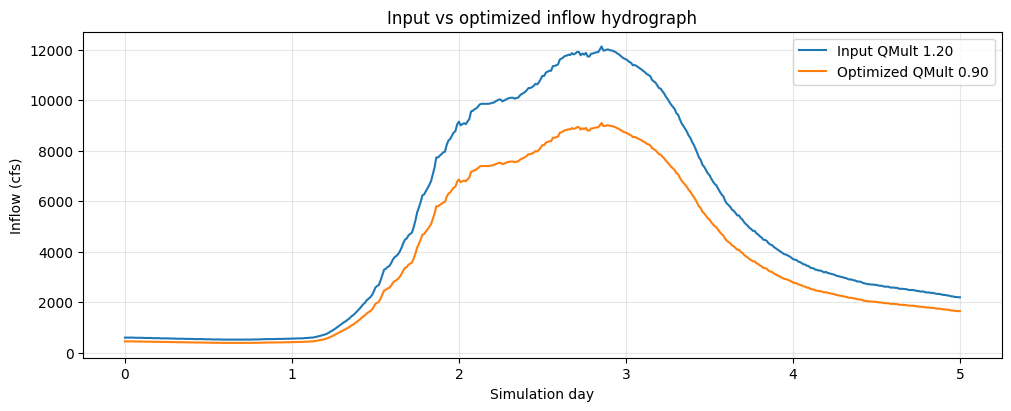

,metric,input,optimized,optimized/input
0,peak flow cfs,12120.000000,9090.000000,0.75
1,volume proxy cfs-days,24975.386719,18731.541016,0.75


In [9]:
if project_available and not fallback_trials.empty:
    baseline_hydrograph = read_inflow_hydrograph(trial_hdfs[Q_MULT_TRIALS[0]])
    optimized_hydrograph = read_inflow_hydrograph(Path(best_trial["hdf_path"]))

    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    ax.plot(baseline_hydrograph["days"], baseline_hydrograph["flow_cfs"], label=f"Input QMult {Q_MULT_TRIALS[0]:.2f}")
    ax.plot(optimized_hydrograph["days"], optimized_hydrograph["flow_cfs"], label=f"Optimized QMult {best_trial['qmult']:.2f}")
    ax.set_xlabel("Simulation day")
    ax.set_ylabel("Inflow (cfs)")
    ax.set_title("Input vs optimized inflow hydrograph")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

    comparison = pd.DataFrame(
        {
            "metric": ["peak flow cfs", "volume proxy cfs-days"],
            "input": [
                baseline_hydrograph["flow_cfs"].max(),
                np.trapezoid(baseline_hydrograph["flow_cfs"], baseline_hydrograph["days"]),
            ],
            "optimized": [
                optimized_hydrograph["flow_cfs"].max(),
                np.trapezoid(optimized_hydrograph["flow_cfs"], optimized_hydrograph["days"]),
            ],
        }
    )
    comparison["optimized/input"] = comparison["optimized"] / comparison["input"]
    display(comparison)

## Objective Function Convergence

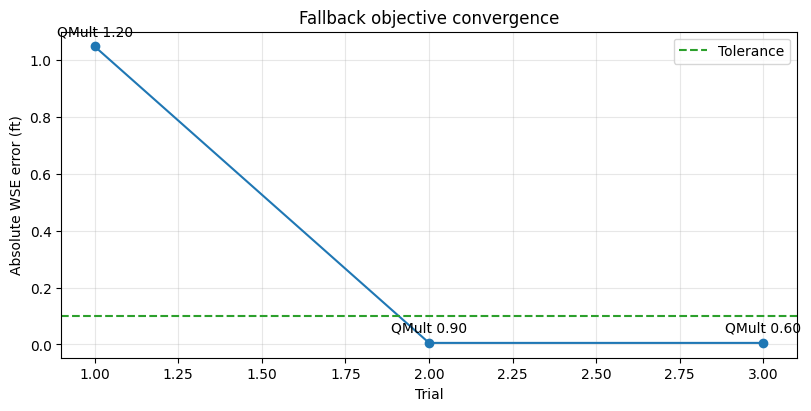

,trial,qmult,computed_wse_ft,target_wse_ft,difference_ft,objective_ft,within_tolerance
0,1,1.2,3964.547363,3963.5,1.047363,1.047363,False
1,2,0.9,3963.494385,3963.5,-0.005615,0.005615,True
2,3,0.6,3963.494385,3963.5,-0.005615,0.005615,True


In [10]:
if project_available and not fallback_trials.empty:
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.plot(fallback_trials["trial"], fallback_trials["objective_ft"], marker="o")
    ax.axhline(TARGET_TOLERANCE, color="tab:green", linestyle="--", label="Tolerance")
    for _, row in fallback_trials.iterrows():
        ax.annotate(f"QMult {row['qmult']:.2f}", (row["trial"], row["objective_ft"]), textcoords="offset points", xytext=(0, 8), ha="center")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Absolute WSE error (ft)")
    ax.set_title("Fallback objective convergence")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

    display(fallback_trials[["trial", "qmult", "computed_wse_ft", "target_wse_ft", "difference_ft", "objective_ft", "within_tolerance"]])

## Before/After WSE Comparison

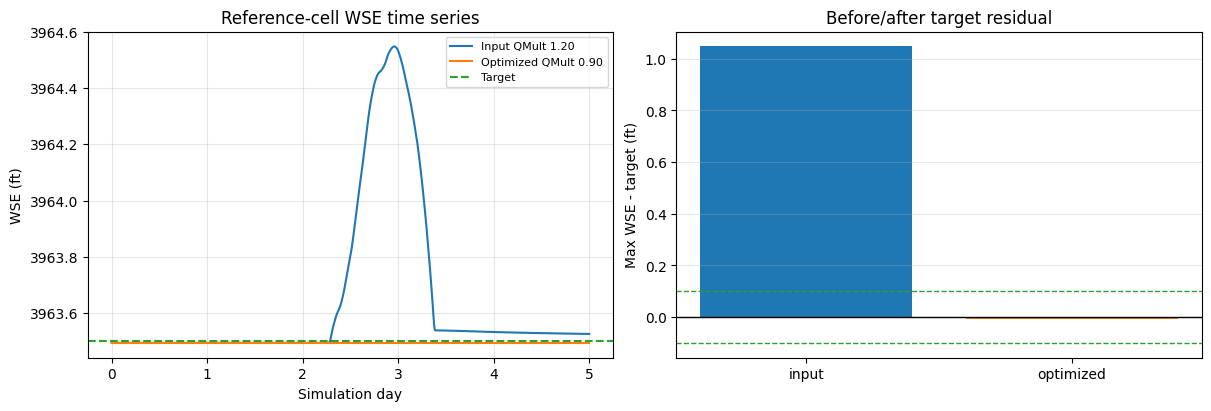

,run,max_wse_ft,difference_from_target_ft
0,input,3964.547363,1.047363
1,optimized,3963.494385,-0.005615


Executed flow hydrograph optimization workflow with before/after WSE comparison.


In [11]:
if project_available and not fallback_trials.empty:
    baseline_wse = read_reference_wse(trial_hdfs[Q_MULT_TRIALS[0]], reference_cell["cell_index"])
    optimized_wse = read_reference_wse(Path(best_trial["hdf_path"]), reference_cell["cell_index"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    axes[0].plot(baseline_wse["days"], baseline_wse["wse_ft"], label=f"Input QMult {Q_MULT_TRIALS[0]:.2f}")
    axes[0].plot(optimized_wse["days"], optimized_wse["wse_ft"], label=f"Optimized QMult {best_trial['qmult']:.2f}")
    axes[0].axhline(TARGET_VALUE, color="tab:green", linestyle="--", label="Target")
    axes[0].set_xlabel("Simulation day")
    axes[0].set_ylabel("WSE (ft)")
    axes[0].set_title("Reference-cell WSE time series")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    before_after = pd.DataFrame(
        {
            "run": ["input", "optimized"],
            "max_wse_ft": [baseline_wse["wse_ft"].max(), optimized_wse["wse_ft"].max()],
        }
    )
    before_after["difference_from_target_ft"] = before_after["max_wse_ft"] - TARGET_VALUE
    axes[1].bar(before_after["run"], before_after["difference_from_target_ft"], color=["tab:blue", "tab:orange"])
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].axhline(TARGET_TOLERANCE, color="tab:green", linestyle="--", linewidth=1)
    axes[1].axhline(-TARGET_TOLERANCE, color="tab:green", linestyle="--", linewidth=1)
    axes[1].set_ylabel("Max WSE - target (ft)")
    axes[1].set_title("Before/after target residual")
    axes[1].grid(True, axis="y", alpha=0.3)
    plt.show()

    display(before_after)

    assert best_trial["objective_ft"] <= TARGET_TOLERANCE
    print("Executed flow hydrograph optimization workflow with before/after WSE comparison.")